## 结论
##### 数据集概览
- `train_essays.csv`（行数=1378）显示出明显的类别不平衡：学生写作样本远多于 大语言模型生成样本（大语言模型 共 3 篇，其中 `prompt_id=1` 有 2 篇，`prompt_id=0` 有 1 篇）。
- `test_essays.csv`（行数=3）：与训练集结构一致，但不包含目标标签，用于提交预测结果。
- `train_prompts.csv`（行数=2）：仅包含 2 个不同提示词，每个提示词都有独立的说明和源文本（可能影响作文风格）。
- `sample_submission.csv`：给出了评测所需的预测结果格式。

##### 关键洞察
- 与更简洁的 大语言模型文本相比，学生作文在长度和复杂度上的分布范围更广。
- 文本分析显示，学生作文与 大语言模型作文在用词上存在可区分差异。
- 学生作文：整体更长、词汇更丰富（平均词数 556.77；平均唯一词数 275.33）。
- 大语言模型作文：整体更短，但平均词长略长（平均词数 260.67；平均唯一词数 146.33），体现了不同的词汇策略。
- 作文与提示词在主题上高度一致，潜在语义分析 一致性得分达到 1.0。
- 在提示词与作文中都高频出现如“选举人团”“总统选举”等双词组，说明主题联系清晰，且作文常扩展到更广泛的社会议题。
- 关键词频率分析表明作文受提示词驱动明显，例如“选举相关”“投票”等词。
- 数字表达分析也能区分写作风格：学生更常用阿拉伯数字，大语言模型 更倾向数字词。

#### 文本指标分析总结

- **学生作文**：
  - 平均词数：556.77 词
  - 平均唯一词数：275.33 词
  - 平均句子数：30.06 句
  - 平均词长：4.69 个字符

- **大语言模型生成作文**：
  - 平均词数：260.67 词
  - 平均唯一词数：146.33 词
  - 平均句子数：13 句
  - 平均词长：4.94 个字符

这些指标进一步说明：学生作文通常更长、更复杂；而 大语言模型文本更简洁，但词长略高。此类文本差异可用于构建更有效的区分特征。

#### 主题分析
- **主题一致性**：使用潜在语义分析（潜在语义分析）后，作文与提示词的主题一致性得分为 1.0，说明学生写作聚焦且贴题。
- **双词组（双词组）**：如“选举人团”“总统选举”等在提示词与作文中共同高频出现；同时作文还引入相关议题，体现学生对更广泛社会问题的延展讨论。
- **关键词**：提示词与作文在“选举相关”“学院”“投票”等关键词上高度重合，说明提示词有效引导了写作方向。

#### 数字表达分析
- **学生作文**：更偏好用阿拉伯数字表达数值，可能反映更口语化或直接的表达习惯。
- **大语言模型生成作文**：在当前小样本下，大语言模型 更常使用数字词而非阿拉伯数字，这可能是区分特征之一。

#### 模型开发的下一步

1. 通过合成数据或过采样增加 大语言模型生成作文样本，缓解类别不平衡问题。
2. 对比多种机器学习算法（传统模型与深度学习模型），筛选最佳方案。
3. 进行系统化超参数优化，进一步提升模型表现。



In [2]:
# 导入常用分析库

import numpy as np  # 线性代数计算
import pandas as pd  # 数据处理与 CSV 读写
import os

# 查看本地数据目录下的文件
for dirname, _, filenames in os.walk("/Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/data/llm-detect-ai-generated-text"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/data/llm-detect-ai-generated-text/train_prompts.csv
/Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/data/llm-detect-ai-generated-text/test_essays.csv
/Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/data/llm-detect-ai-generated-text/train_essays.csv
/Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/data/llm-detect-ai-generated-text/sample_submission.csv


## 引言


我们有三个主要数据文件：

- `train_essays.csv`：训练集，包含学生写作作文和少量 大语言模型生成作文样本。
- `test_essays.csv`：测试集，需要预测每篇作文是否由 大语言模型生成。
- `train_prompts.csv`：用于生成作文的提示词，包含写作说明与源文本。

第一步先加载这些文件，并对其内容形成直观认识。


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 定义文件路径
DATA_DIR = "/Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/data/llm-detect-ai-generated-text"
train_essays_path = os.path.join(DATA_DIR, "train_essays.csv")
test_essays_path = os.path.join(DATA_DIR, "test_essays.csv")
train_prompts_path = os.path.join(DATA_DIR, "train_prompts.csv")

# 加载数据
train_essays_df = pd.read_csv(train_essays_path)
test_essays_df = pd.read_csv(test_essays_path)
train_prompts_df = pd.read_csv(train_prompts_path)


In [4]:
# 查看训练作文前几行
train_essays_df.tail()

,id,prompt_id,text,generated
1373,fe6ff9a5,1,There has been a fuss about the Elector Colleg...,0
1374,ff669174,0,Limiting car usage has many advantages. Such a...,0
1375,ffa247e0,0,There's a new trend that has been developing f...,0
1376,ffc237e9,0,As we all know cars are a big part of our soci...,0
1377,ffe1ca0d,0,Cars have been around since the 1800's and hav...,0


In [5]:
# 查看测试作文前几行
test_essays_df.tail()

,id,prompt_id,text
0,0000aaaa,2,Aaa bbb ccc.
1,1111bbbb,3,Bbb ccc ddd.
2,2222cccc,4,CCC ddd eee.


In [6]:
# 查看 train_prompts 前几行
train_prompts_df.tail()

,prompt_id,prompt_name,instructions,source_text
0,0,Car-free cities,Write an explanatory essay to inform fellow ci...,"# In German Suburb, Life Goes On Without Cars ..."
1,1,Does the electoral college work?,Write a letter to your state senator in which ...,# What Is the Electoral College? by the Office...


## 探索性数据分析


In [7]:
# 检查各数据集缺失值
missing_values_train = train_essays_df.isnull().sum()
print("missing_values_train:", missing_values_train)
missing_values_test = test_essays_df.isnull().sum()
print("\nmissing_values_train:", missing_values_train)
missing_values_prompts = train_prompts_df.isnull().sum()
print("\nmissing_values_prompts:", missing_values_prompts)

missing_values_train: id           0
prompt_id    0
text         0
generated    0
dtype: int64

missing_values_train: id           0
prompt_id    0
text         0
generated    0
dtype: int64

missing_values_prompts: prompt_id       0
prompt_name     0
instructions    0
source_text     0
dtype: int64


在任何分类任务中，理解类别分布都非常关键。数据集不平衡会显著影响预测模型表现，往往需要采用专门方法处理。

下面我们先查看训练集中学生作文与 大语言模型生成作文的数量平衡情况。


In [8]:
# 查看 generated 列分布
train_essays_df['generated'].value_counts()

generated
0    1375
1       3
Name: count, dtype: int64

`train_essays_df` 数据框显示类别分布极不平衡：学生作文（标签 `0`）有 1375 篇，而 大语言模型生成作文（标签 `1`）仅有 3 篇。


In [9]:
llm_generated_counts = train_essays_df[train_essays_df['generated'] == 1]['prompt_id'].value_counts()
llm_generated_counts

prompt_id
1    2
0    1
Name: count, dtype: int64

## 文本长度分析


接下来我们分析作文长度，这可能是判断作文由学生还是 大语言模型生成的一个指示性特征。

我们将计算每篇作文的长度，并比较两类样本的分布差异。


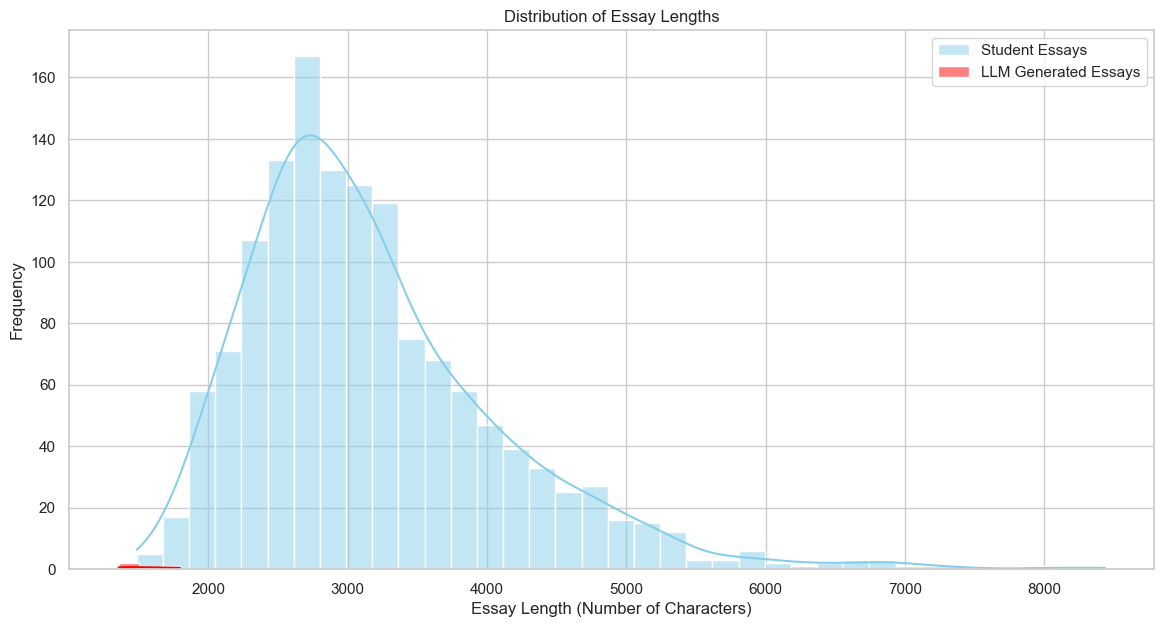

In [10]:
# 计算每篇作文长度并新增列
train_essays_df['essay_length'] = train_essays_df['text'].apply(len)

sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))

# 学生作文长度分布
sns.histplot(train_essays_df[train_essays_df['generated'] == 0]['essay_length'], color="skyblue", label='Student Essays', kde=True)

# 大语言模型生成作文长度分布
sns.histplot(train_essays_df[train_essays_df['generated'] == 1]['essay_length'], color="red", label='LLM Generated Essays', kde=True)

plt.title('Distribution of Essay Lengths')
plt.xlabel('Essay Length (Number of Characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

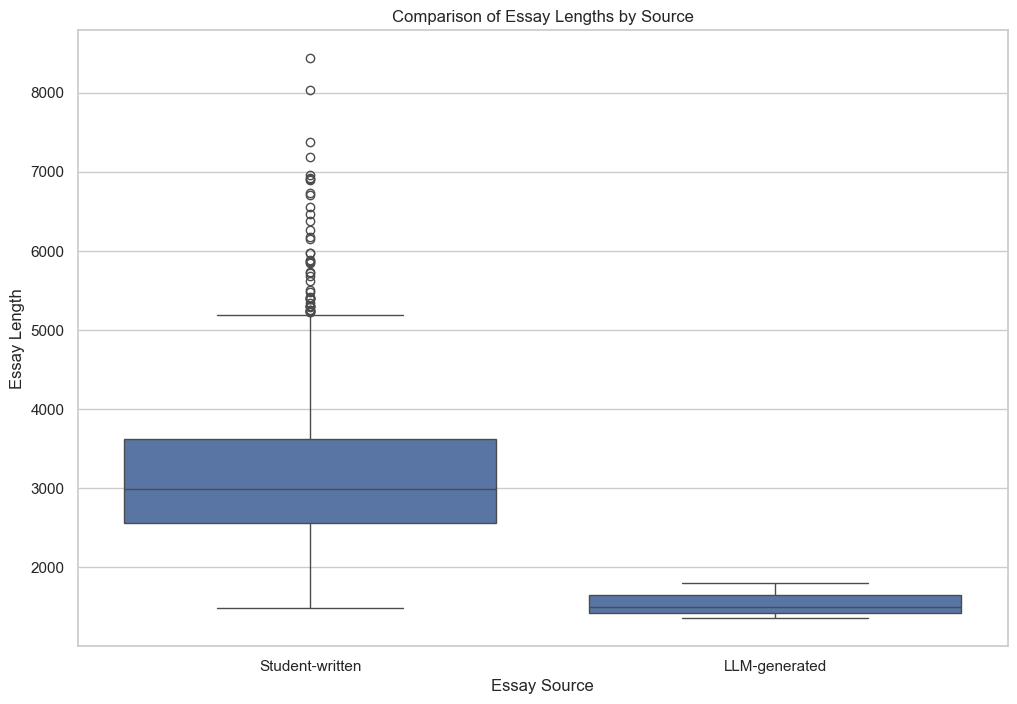

In [11]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='generated', y='essay_length', data=train_essays_df)
plt.title('Comparison of Essay Lengths by Source')
plt.xlabel('Essay Source')
plt.ylabel('Essay Length')
plt.xticks([0, 1], ['Student-written', 'LLM-generated'])
plt.show()


学生作文长度分布更广，且通常比当前少量 大语言模型生成作文更长。


In [12]:
def calculate_text_metrics_simple(text):
    words = text.split()
    sentences = text.split('.')
    word_count = len(words)
    unique_word_count = len(set(words))
    sentence_count = len(sentences)
    avg_word_length = sum(len(word) for word in words) / word_count if word_count > 0 else 0
    return word_count, unique_word_count, sentence_count, avg_word_length

# 将函数应用到 text 列
train_essays_df['metrics'] = train_essays_df['text'].apply(calculate_text_metrics_simple)

# 将 metrics 列展开为多个列
train_essays_df[['word_count', 'unique_word_count', 'sentence_count', 'avg_word_length']] = pd.DataFrame(train_essays_df['metrics'].tolist(), index=train_essays_df.index)

# 删除不再需要的 metrics 列
train_essays_df.drop('metrics', axis=1, inplace=True)

# 按 generated 分组，比较学生作文与大语言模型生成作文指标
comparison_metrics = train_essays_df.groupby('generated')[['word_count', 'unique_word_count', 'sentence_count', 'avg_word_length']].mean()
comparison_metrics


,word_count,unique_word_count,sentence_count,avg_word_length
generated,,,,
0,556.768727,275.334545,30.063273,4.694868
1,260.666667,146.333333,13.000000,4.935610


## 高频词分析


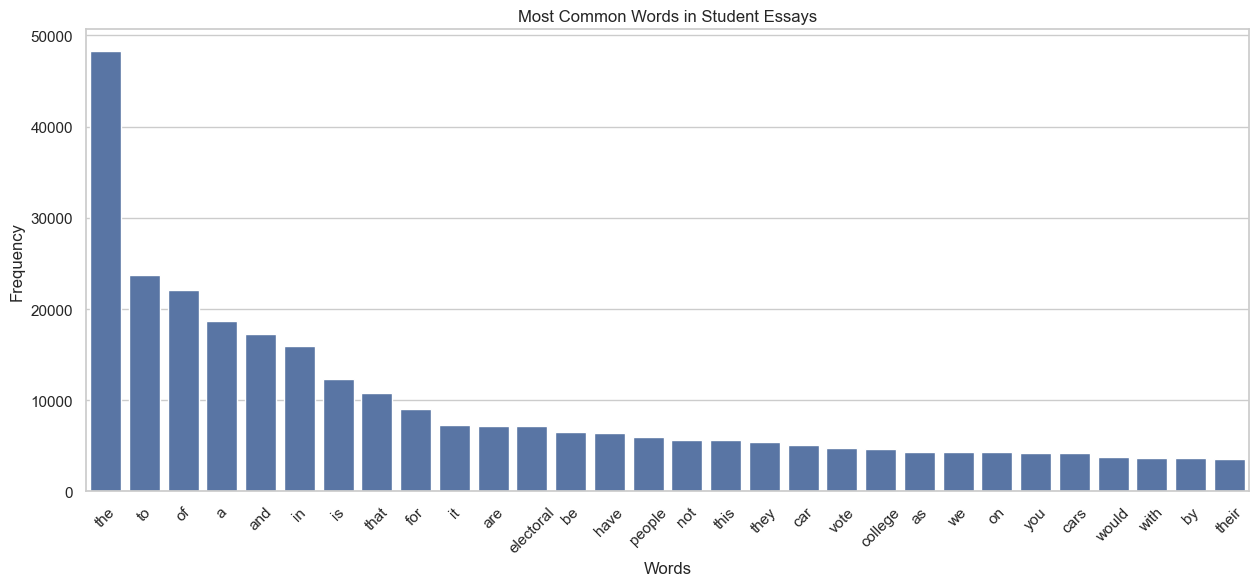

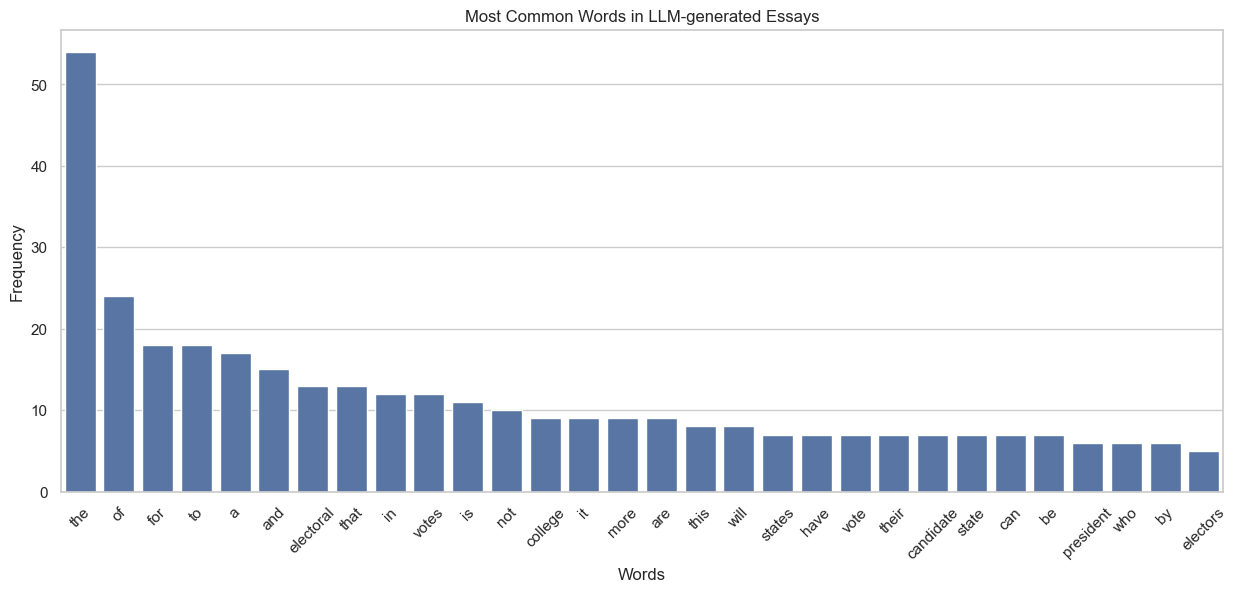

In [13]:
from collections import Counter
import itertools

def plot_most_common_words(text_series, num_words=30, title="Most Common Words"):
    all_text = ' '.join(text_series).lower()
    words = all_text.split()
    word_freq = Counter(words)
    common_words = word_freq.most_common(num_words)
    
    # 绘制高频词
    plt.figure(figsize=(15, 6))
    sns.barplot(x=[word for word, freq in common_words], y=[freq for word, freq in common_words])
    plt.title(title)
    plt.xticks(rotation=45)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.show()

plot_most_common_words(train_essays_df[train_essays_df['generated'] == 0]['text'], title="Most Common Words in Student Essays")
plot_most_common_words(train_essays_df[train_essays_df['generated'] == 1]['text'], title="Most Common Words in LLM-generated Essays")

学生作文与 大语言模型生成文本的常见词存在差异，提示可以利用潜在语言模式进行分类。


## 提示词与作文关系分析



为理解提示词如何影响作文，将分析 `train_prompts_df` 与 `train_essays_df` 之间的关联。这包括提示词使用频率、各提示词对应作文平均长度，以及提示词与作文之间的主题联系。


In [14]:
train_prompts_ex = train_prompts_df.iloc[0]
print(train_prompts_df.columns)

Index(['prompt_id', 'prompt_name', 'instructions', 'source_text'], dtype='object')


In [15]:
# 以结构化 Markdown 形式展示每列内容
from IPython.display import display, Markdown

display(Markdown(f"### Prompt Name:\n{train_prompts_ex['prompt_name']}"))
display(Markdown("====="))
display(Markdown(f"### Instructions:\n{train_prompts_ex['instructions']}"))
display(Markdown("====="))
display(Markdown(f"### Source Text:\n (The text of the article(s) the essays were written in response to)"))

### Prompt Name:
Car-free cities

=====

### Instructions:
Write an explanatory essay to inform fellow citizens about the advantages of limiting car usage. Your essay must be based on ideas and information that can be found in the passage set. Manage your time carefully so that you can read the passages; plan your response; write your response; and revise and edit your response. Be sure to use evidence from multiple sources; and avoid overly relying on one source. Your response should be in the form of a multiparagraph essay. Write your essay in the space provided.

=====

### Source Text:
 (The text of the article(s) the essays were written in response to)

### Prompt Usage Frequency

prompt_id
0    708
1    670
Name: count, dtype: int64

### Average Essay Length by Prompt

prompt_id
0    3251.927966
1    3081.473134
Name: essay_length, dtype: float64

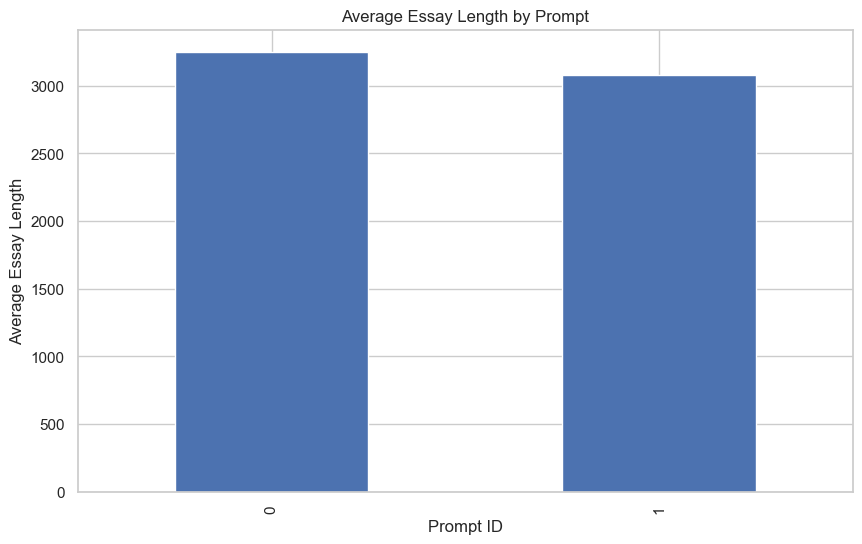

In [16]:

train_essays_df['essay_length'] = train_essays_df['text'].apply(len)

merged_df = train_essays_df.merge(train_prompts_df, on='prompt_id', how='left')

# 分析提示词使用频率
prompt_usage = merged_df['prompt_id'].value_counts()

# 按提示词统计平均作文长度
avg_length_by_prompt = merged_df.groupby('prompt_id')['essay_length'].mean()

# 显示提示词频率
display(Markdown("### Prompt Usage Frequency"))
display(prompt_usage)

# 显示各提示词平均作文长度
display(Markdown("### Average Essay Length by Prompt"))
display(avg_length_by_prompt)

# 绘制各提示词平均作文长度
plt.figure(figsize=(10, 6))
avg_length_by_prompt.plot(kind='bar')
plt.title('Average Essay Length by Prompt')
plt.xlabel('Prompt ID')
plt.ylabel('Average Essay Length')
plt.show()


top_words: [('electoral', np.int64(44)), ('vote', np.int64(36)), ('electors', np.int64(31)), ('car', np.int64(28)), ('college', np.int64(27)), ('president', np.int64(25)), ('state', np.int64(23)), ('election', np.int64(21)), ('votes', np.int64(20)), ('cars', np.int64(19))]


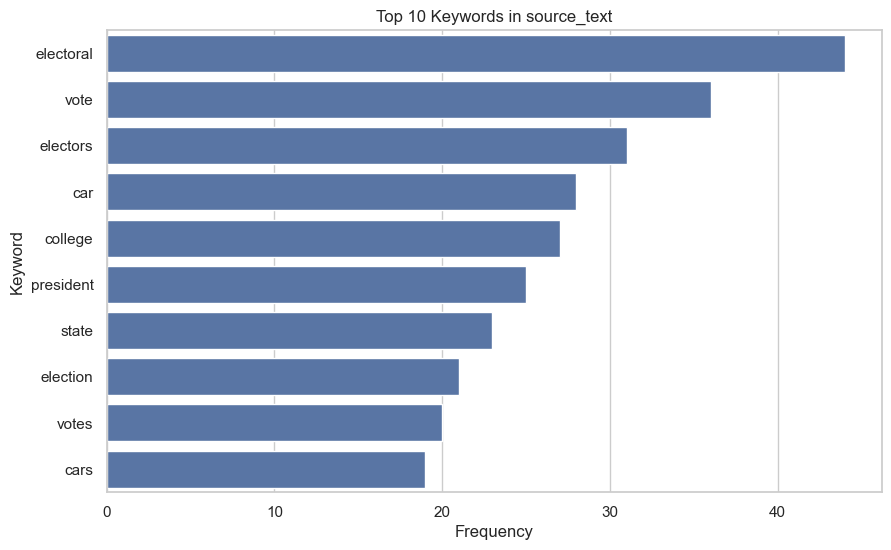


top_words: [('electoral', np.int64(7234)), ('people', np.int64(6924)), ('college', np.int64(6081)), ('vote', np.int64(6000)), ('car', np.int64(5888)), ('cars', np.int64(5731)), ('states', np.int64(4132)), ('president', np.int64(3615)), ('votes', np.int64(2536)), ('electors', np.int64(2515))]


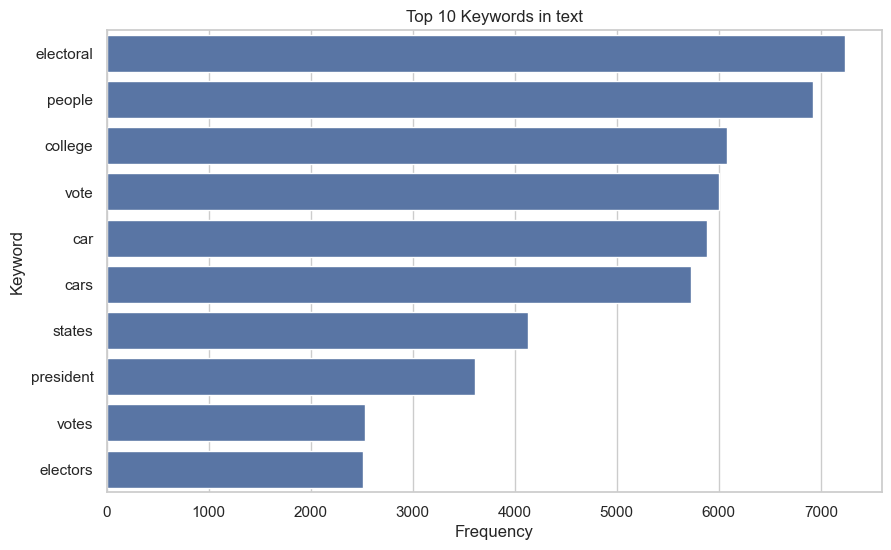

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

def plot_top_keywords(data, column, num_keywords=10):
    vec = CountVectorizer(stop_words='english').fit(data[column])
    bag_of_words = vec.transform(data[column])
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    top_words = words_freq[:num_keywords]
    print("\ntop_words:", top_words)
    # 转为 DataFrame
    top_df = pd.DataFrame(top_words, columns=['Keyword', 'Frequency'])
    
    # 绘图
    plt.figure(figsize=(10,6))
    sns.barplot(x='Frequency', y='Keyword', data=top_df)
    plt.title(f'Top {num_keywords} Keywords in {column}')
    plt.show()

# 绘图 top keywords for prompts
plot_top_keywords(train_prompts_df, 'source_text')

# 绘图 top keywords for essays
plot_top_keywords(train_essays_df, 'text')

## 主题分析：关键词

对 `train_prompts.csv` 中 `source_text` 与 `train_essays.csv` 中 `text` 的高频关键词进行对比后可以发现，提示词与作文在主题上高度一致。`选举相关`、`学院`、`投票`、`总统` 等词在两者中都很突出，说明学生基本围绕提示词核心主题展开写作。这种重合也说明提示词对写作方向具有较强引导作用。

- **提示词**：`选举相关`、`投票`、`选举人`、`学院` 等关键词高频出现，体现出对选举过程的聚焦。
- **作文**：这些关键词同样高频出现（例如 `选举相关` 出现 7234 次，`学院` 出现 6081 次），说明作文与提示词高度相关。此外，`民众`、`各州` 等词也较多，表明作文将选举主题扩展到更广泛的社会语境。

作文中大量出现的主题相关词汇，也可为区分学生作文与 大语言模型生成作文的机器学习模型提供有价值的特征。


In [18]:
def get_top_n_grams(corpus, n=None, n_grams=2):
    vec = CountVectorizer(ngram_range=(n_grams, n_grams), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# 获取提示词中前 10 个高频双词组
top_bigrams_prompts = get_top_n_grams(train_prompts_df['source_text'], n=10, n_grams=2)

# 获取作文中前 10 个高频双词组
top_bigrams_essays = get_top_n_grams(train_essays_df['text'], n=10, n_grams=2)

# 显示提示词与作文的高频双词组
print("Top 10 Bigrams in Prompts:")
for bigram, freq in top_bigrams_prompts:
    print(f"{bigram}: {freq}")

print("\nTop 10 Bigrams in Essays:")
for bigram, freq in top_bigrams_essays:
    print(f"{bigram}: {freq}")

Top 10 Bigrams in Prompts:
electoral college: 27
electoral votes: 11
popular vote: 9
new york: 8
united states: 7
york times: 6
times company: 6
car free: 5
electoral vote: 5
elisabeth rosenthal: 4

Top 10 Bigrams in Essays:
electoral college: 5794
car usage: 1998
popular vote: 1737
united states: 1179
limiting car: 1158
electoral votes: 689
vote president: 676
air pollution: 535
use cars: 518
greenhouse gas: 448


## 主题分析：双词组

词组统计 分析显示，提示词与作文中存在一些共同高频双词组，有助于理解反复出现的主题与表达：

- **提示词**：如 `选举人团`、`投票制度` 等双词组高频出现，表明内容聚焦选举机制；`总统选举`、`普选票` 等短语也体现了对民主原则和投票机制的讨论。

- **作文**：作文中同样高频出现 `选举人团`、`总统选举` 等双词组；同时还出现 `气候变化`、`经济影响` 等表达，说明学生会把提示词主题延伸到更广泛社会议题。

该分析既验证了作文与提示词的主题一致性，也揭示了学生对相关话题的拓展路径。这些短语模式可用于特征工程，帮助模型区分学生作文与 大语言模型生成文本。


### 主题一致性分析


主题一致性可以通过观察作文是否持续围绕同一主题来衡量。常用做法是使用潜在语义分析（潜在语义分析）将作文与提示词映射到低维空间，再计算相似度。


In [19]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import Normalizer


def calculate_thematic_coherence(essays, prompts):
    vectorizer = TfidfVectorizer(stop_words='english')
    dtm = vectorizer.fit_transform(essays + prompts)

    lsa = TruncatedSVD(n_components=1)
    dtm_lsa = lsa.fit_transform(dtm)
    dtm_lsa = Normalizer(copy=False).fit_transform(dtm_lsa)

    essay_vectors = dtm_lsa[:len(essays)]
    prompt_vectors = dtm_lsa[len(essays):]

    coherence_scores = cosine_similarity(essay_vectors, prompt_vectors)
    return coherence_scores.mean()

# 计算作文与提示词的主题一致性
coherence_score = calculate_thematic_coherence(
    list(train_essays_df['text']), 
    list(train_prompts_df['source_text'])
)

print(f"Thematic Coherence Score: {coherence_score}")

Thematic Coherence Score: 1.0


## 主题分析：一致性
- **主题一致性**：基于潜在语义分析（潜在语义分析）的结果显示，一致性得分达到 1.0，说明作文与提示词在主题上完全对齐，体现出较强的贴题性与结构性。这种高相关特征，可能是区分学生写作与 大语言模型生成文本的重要信号。


## 数字书写风格分析


In [20]:
import re
import pandas as pd

# 定义数字与数字词的正则模式
numeral_pattern = re.compile(r'\b\d+\b')  # Matches any whole number
word_number_pattern = re.compile(
    r'\b(one|two|three|four|five|six|seven|eight|nine|ten)\b', re.IGNORECASE)  # Matches number words from one to ten

# 统计阿拉伯数字与数字词出现次数的函数
def count_digit_styles(text, numeral_regex, word_number_regex):
    numeral_matches = len(re.findall(numeral_regex, text))
    word_number_matches = len(re.findall(word_number_regex, text))
    return numeral_matches, word_number_matches

# 复制切片以避免 SettingWithCopyWarning
train_essays_df = train_essays_df.copy()

# 对作文应用该函数
train_essays_df[['numerals', 'number_words']] = train_essays_df['text'].apply(
    lambda x: count_digit_styles(x, numeral_pattern, word_number_pattern)).apply(pd.Series)

# 根据 generated 标记拆分学生作文与大语言模型作文
student_essays = train_essays_df[train_essays_df['generated'] == 0]
llm_essays = train_essays_df[train_essays_df['generated'] == 1]

# 汇总结果
student_numerals = student_essays['numerals'].sum()
student_number_words = student_essays['number_words'].sum()
llm_numerals = llm_essays['numerals'].sum()
llm_number_words = llm_essays['number_words'].sum()

# 输出结果
print(f"Student Essays - Numerals: {student_numerals}, Number Words: {student_number_words}")
print(f"LLM Essays - Numerals: {llm_numerals}, Number Words: {llm_number_words}")

# 计算平均值
avg_student_numerals = student_numerals / len(student_essays)
avg_student_number_words = student_number_words / len(student_essays)
avg_llm_numerals = llm_numerals / len(llm_essays) if len(llm_essays) > 0 else 0
avg_llm_number_words = llm_number_words / len(llm_essays) if len(llm_essays) > 0 else 0

# 输出平均结果
print()
print(f"Average Numerals per Student Essay: {avg_student_numerals:.2f}")
print(f"Average Number Words per Student Essay: {avg_student_number_words:.2f}")
print()
print(f"Average Numerals per LLM Essay: {avg_llm_numerals:.2f}")
print(f"Average Number Words per LLM Essay: {avg_llm_number_words:.2f}")

Student Essays - Numerals: 7757, Number Words: 3747
LLM Essays - Numerals: 3, Number Words: 6

Average Numerals per Student Essay: 5.64
Average Number Words per Student Essay: 2.73

Average Numerals per LLM Essay: 1.00
Average Number Words per LLM Essay: 2.00


作文中的数字表达方式可以反映学生与 大语言模型 的写作风格差异。本分析统计了阿拉伯数字和数字词在作文中的出现频率。

### 结果：

- **学生作文**：
  - 阿拉伯数字：7757 次
  - 数字词：3747 次

- **大语言模型生成作文**：
  - 阿拉伯数字：3 次
  - 数字词：6 次

### 数字使用分析

- **学生作文**：平均每篇更常使用阿拉伯数字（5.64 次）而非数字词（2.73 次），说明更倾向直接数字表达。
- **大语言模型生成作文**：受样本量很小（仅 3 篇）影响，观察到阿拉伯数字使用（1.00 次）少于数字词（2.00 次）。该趋势需谨慎解读，未必能代表更大范围的 大语言模型 行为。


## 聚类分析


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import string

# 文本预处理函数
def preprocess_text(text):
    # 小写化并移除标点和数字
    text = re.sub(r'[^\w\s]', '', text.lower())
    text = re.sub(r'\d+', '', text)
    # 分词并移除停用词
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    # 执行词干提取
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

# 预处理作文文本
train_essays_df['preprocessed_text'] = train_essays_df['text'].apply(preprocess_text)

# 对作文进行向量化
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(train_essays_df['preprocessed_text'])

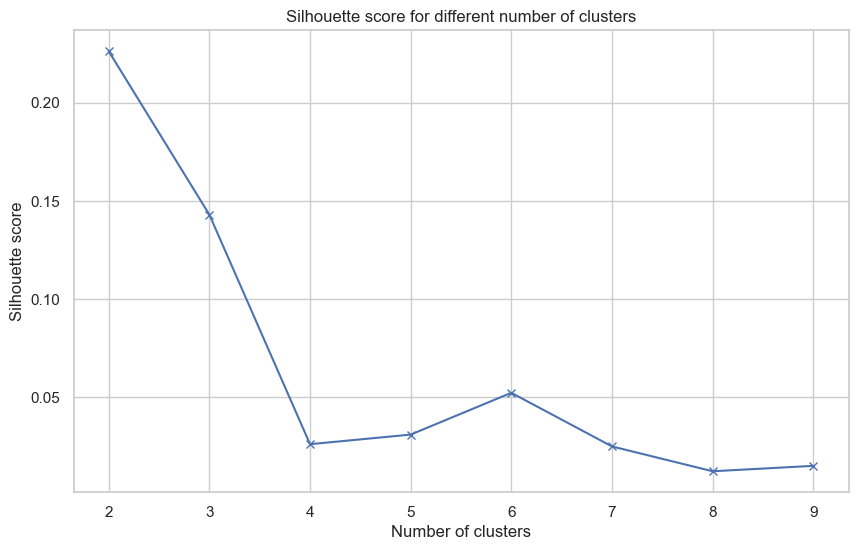

np.int64(2)

In [22]:
# 使用轮廓系数确定最佳聚类数
range_n_clusters = list(range(2, 10))
silhouette_avg = []
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, n_init='auto')
    kmeans.fit(tfidf_matrix)
    cluster_labels = kmeans.labels_
    silhouette_avg.append(silhouette_score(tfidf_matrix, cluster_labels))

# 绘图 the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for different number of clusters')
plt.show()

# 找出轮廓系数最高对应的聚类数
optimal_num_clusters = np.argmax(silhouette_avg) + 2  # Adding 2 because range starts at 2
optimal_num_clusters

In [23]:
kmeans = KMeans(n_clusters=2, random_state=1, n_init='auto')
clusters = kmeans.fit_predict(tfidf_matrix)

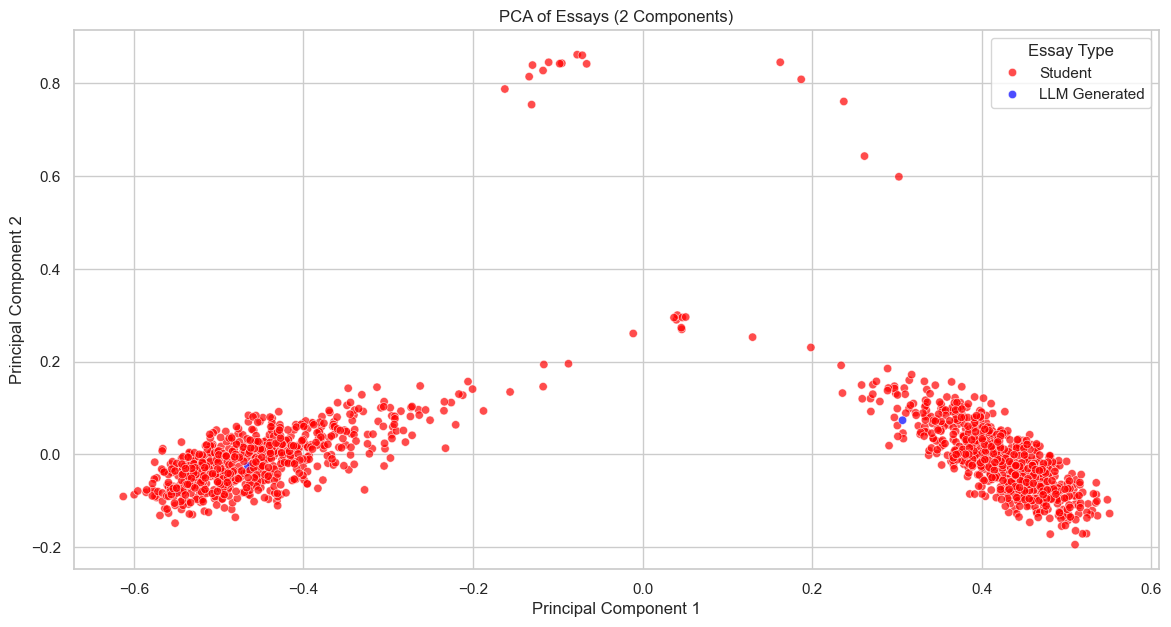

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# 使用 PCA 将数据降到 2 维用于可视化
pca = PCA(n_components=2)
reduced_X_sample = pca.fit_transform(tfidf_matrix.toarray())  # Replace with actual TF-IDF matrix

# 将 PCA 结果加入数据框
pca_df = pd.DataFrame(reduced_X_sample, columns=['PC1', 'PC2'])
pca_df['generated'] = train_essays_df['generated']

# 自定义绘图配色
custom_palette = {0: "red", 1: "blue"}
plt.figure(figsize=(14, 7))
sns.scatterplot(
    x='PC1', y='PC2', hue='generated', data=pca_df, 
    palette=custom_palette, alpha=0.7
)
plt.title('PCA of Essays (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Student', 'LLM Generated'], title='Essay Type')

plt.show()

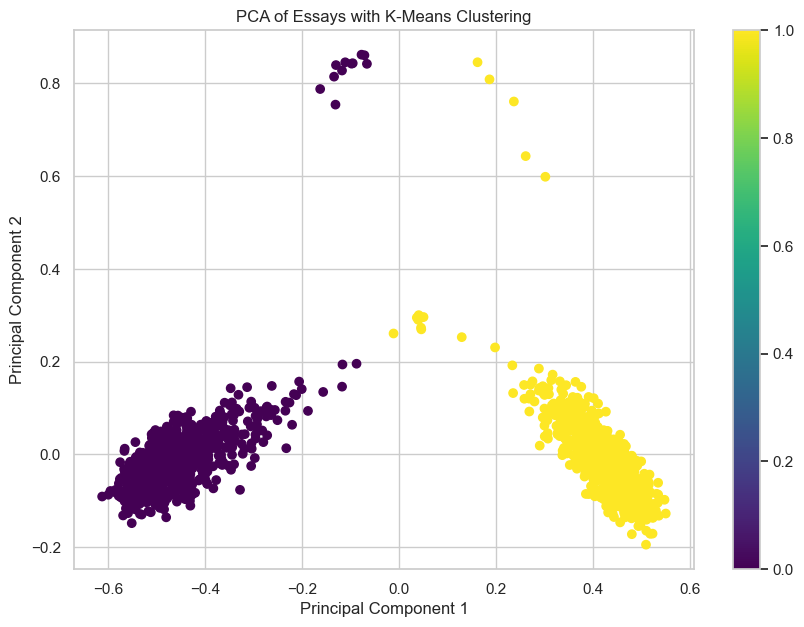

In [25]:
plt.figure(figsize=(10, 7))
plt.scatter(reduced_X_sample[:, 0], reduced_X_sample[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title('PCA of Essays with K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()
plt.show()

这些聚类很可能分别对应于各个题目提示词下的作文。


In [26]:
def plot_pca_for_prompt(prompt_id, df, tfidf_vectorizer):
    # 对指定 prompt_id 执行 PCA 并绘图
    # 筛选指定 prompt_id 的作文
    prompt_df = df[df['prompt_id'] == prompt_id]
    tfidf_matrix = tfidf_vectorizer.transform(prompt_df['preprocessed_text'])
    
    # 应用 PCA
    pca = PCA(n_components=2, random_state=42)
    reduced_data = pca.fit_transform(tfidf_matrix.toarray())  # Convert to dense array for PCA
    
    # 创建 PCA 结果数据框
    pca_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])
    pca_df['generated'] = prompt_df['generated'].values  # Match indices
    
    # 绘图ting the PCA results
    plt.figure(figsize=(14, 7))
    scatter_plot = sns.scatterplot(
        x='PC1', y='PC2', hue='generated', data=pca_df, 
        palette=custom_palette, alpha=0.7
    )
    plt.title(f'PCA of Essays for Prompt {prompt_id}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')

    # 手动定义 handles 和 labels 修正图例
    handles, labels = scatter_plot.get_legend_handles_labels()
    plt.legend(handles, ['Student', 'LLM Generated'], title='Essay Type')
    
    plt.show()

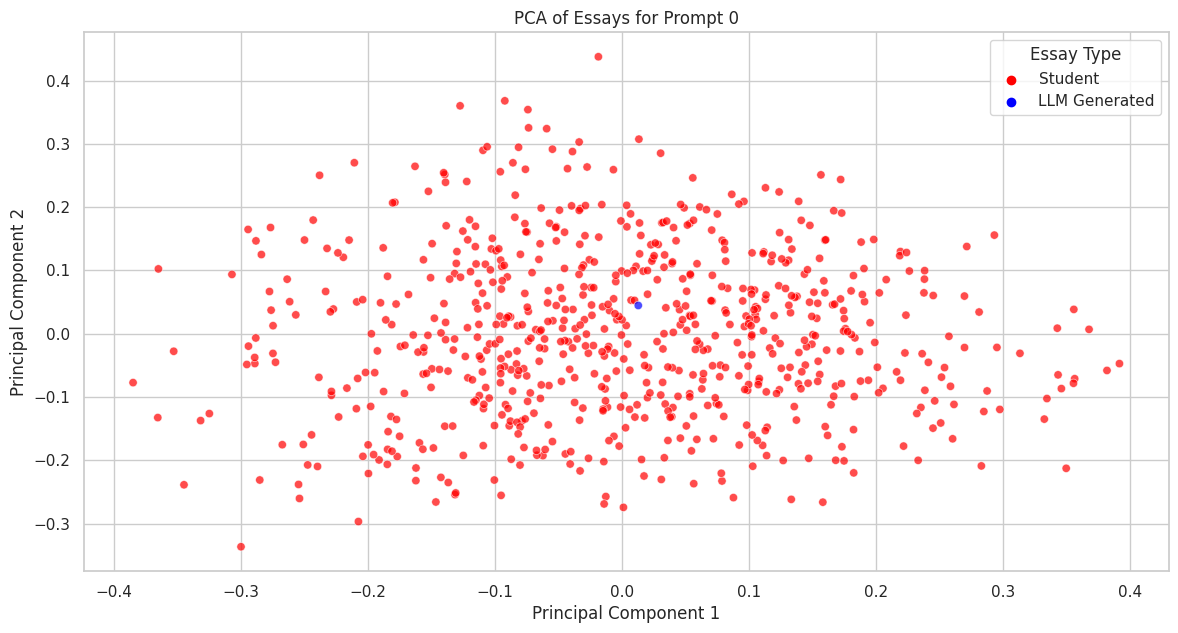

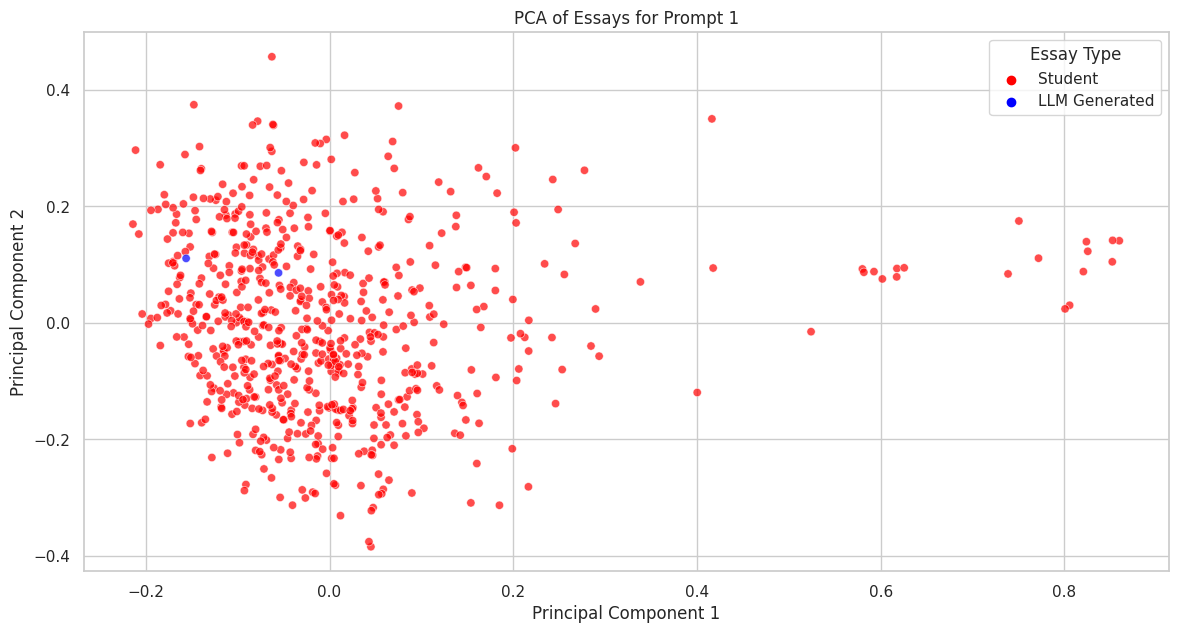

In [26]:
# 对 prompt_id=0 执行 PCA 并绘图
plot_pca_for_prompt(0, train_essays_df, tfidf_vectorizer)

# 对 prompt_id=1 执行 PCA 并绘图
plot_pca_for_prompt(1, train_essays_df, tfidf_vectorizer)

主成分分析可视化显示，大语言模型生成作文与学生作文存在一定混合，说明在风格和内容上有相似性。后续可尝试预训练语言模型的文本嵌入等更高级方法，以挖掘更深层语义差异。
